In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/harpartapsingh13/mental-health-prediction-dataset/mental_health_prediction.csv


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [69]:
df = pd.read_csv("/kaggle/input/datasets/harpartapsingh13/mental-health-prediction-dataset/mental_health_prediction.csv")

In [70]:
df.head()

,age,gender,occupation,sleep_hours,sleep_quality,social_media_hours,academic_work_pressure,physical_activity_days,stress_level,anxiety_score,depression_score,work_life_balance,mood_score,concentration_level,social_support,mental_health_condition,severity,treatment
0,15,Female,Student,6.7,8.0,1.0,3.0,4.0,1.0,2.0,1.0,7.0,8.0,6.0,8.0,Normal,Mild,No treatment needed; maintain healthy lifestyl...
1,15,Female,Working Professional,7.8,7.0,1.5,4.0,5.0,3.0,2.0,4.0,8.0,10.0,8.0,6.0,Normal,Mild,No treatment needed; maintain healthy lifestyl...
2,15,Female,Student,7.0,3.0,4.0,6.0,3.0,3.0,10.0,6.0,4.0,4.0,5.0,5.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."
3,15,Female,Both (Part-time work + Study),7.3,2.0,4.6,6.0,2.0,4.0,7.0,8.0,1.0,5.0,4.0,5.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."
4,15,Female,Student,5.0,6.0,4.3,7.0,1.0,7.0,5.0,5.0,1.0,4.0,2.0,6.0,Anxiety,Moderate,"Cognitive Behavioral Therapy (CBT), mindfulnes..."


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      500 non-null    int64  
 1   gender                   500 non-null    object 
 2   occupation               500 non-null    object 
 3   sleep_hours              485 non-null    float64
 4   sleep_quality            479 non-null    float64
 5   social_media_hours       481 non-null    float64
 6   academic_work_pressure   467 non-null    float64
 7   physical_activity_days   480 non-null    float64
 8   stress_level             472 non-null    float64
 9   anxiety_score            478 non-null    float64
 10  depression_score         478 non-null    float64
 11  work_life_balance        482 non-null    float64
 12  mood_score               480 non-null    float64
 13  concentration_level      479 non-null    float64
 14  social_support           4

In [72]:
df.describe()

,age,sleep_hours,sleep_quality,social_media_hours,academic_work_pressure,physical_activity_days,stress_level,anxiety_score,depression_score,work_life_balance,mood_score,concentration_level,social_support
count,500.000000,485.000000,479.000000,481.000000,467.000000,480.000000,472.000000,478.000000,478.000000,482.000000,480.000000,479.000000,470.000000
mean,26.832000,6.769691,4.822547,4.235343,6.100642,1.606250,5.993644,4.763598,4.953975,3.784232,4.377083,4.496868,4.489362
std,7.735597,1.939245,2.099968,2.002300,2.229470,1.589751,2.549294,2.338398,2.437043,2.523717,2.354203,2.370383,2.369604
min,15.000000,3.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,21.000000,5.300000,3.000000,2.600000,4.000000,0.000000,4.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000
50%,26.000000,6.700000,5.000000,4.300000,6.000000,1.000000,6.000000,5.000000,5.000000,3.000000,4.000000,4.000000,4.000000
75%,32.000000,8.100000,6.000000,5.800000,8.000000,3.000000,8.000000,7.000000,7.000000,6.000000,6.000000,6.000000,7.000000
max,52.000000,12.000000,10.000000,9.300000,10.000000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [73]:
df.describe(include = "object")

,gender,occupation,mental_health_condition,severity,treatment
count,500,500,500,500,500
unique,3,3,4,3,4
top,Non-binary,Both (Part-time work + Study),Normal,Mild,No treatment needed; maintain healthy lifestyl...
freq,178,185,125,242,125


In [74]:
df.isna().sum()

age                         0
gender                      0
occupation                  0
sleep_hours                15
sleep_quality              21
social_media_hours         19
academic_work_pressure     33
physical_activity_days     20
stress_level               28
anxiety_score              22
depression_score           22
work_life_balance          18
mood_score                 20
concentration_level        21
social_support             30
mental_health_condition     0
severity                    0
treatment                   0
dtype: int64

In [75]:
df = df.dropna()

In [76]:
df.duplicated().sum()

np.int64(0)

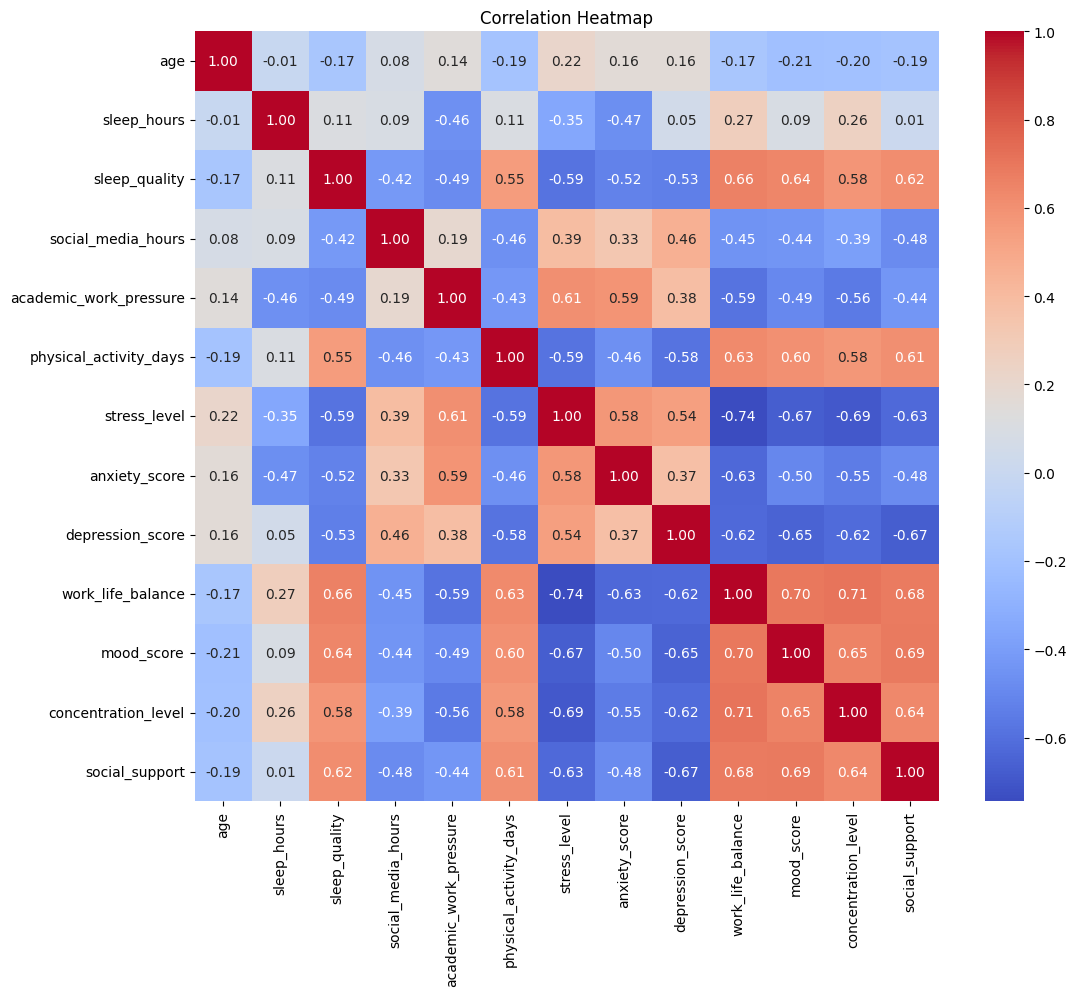

In [77]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

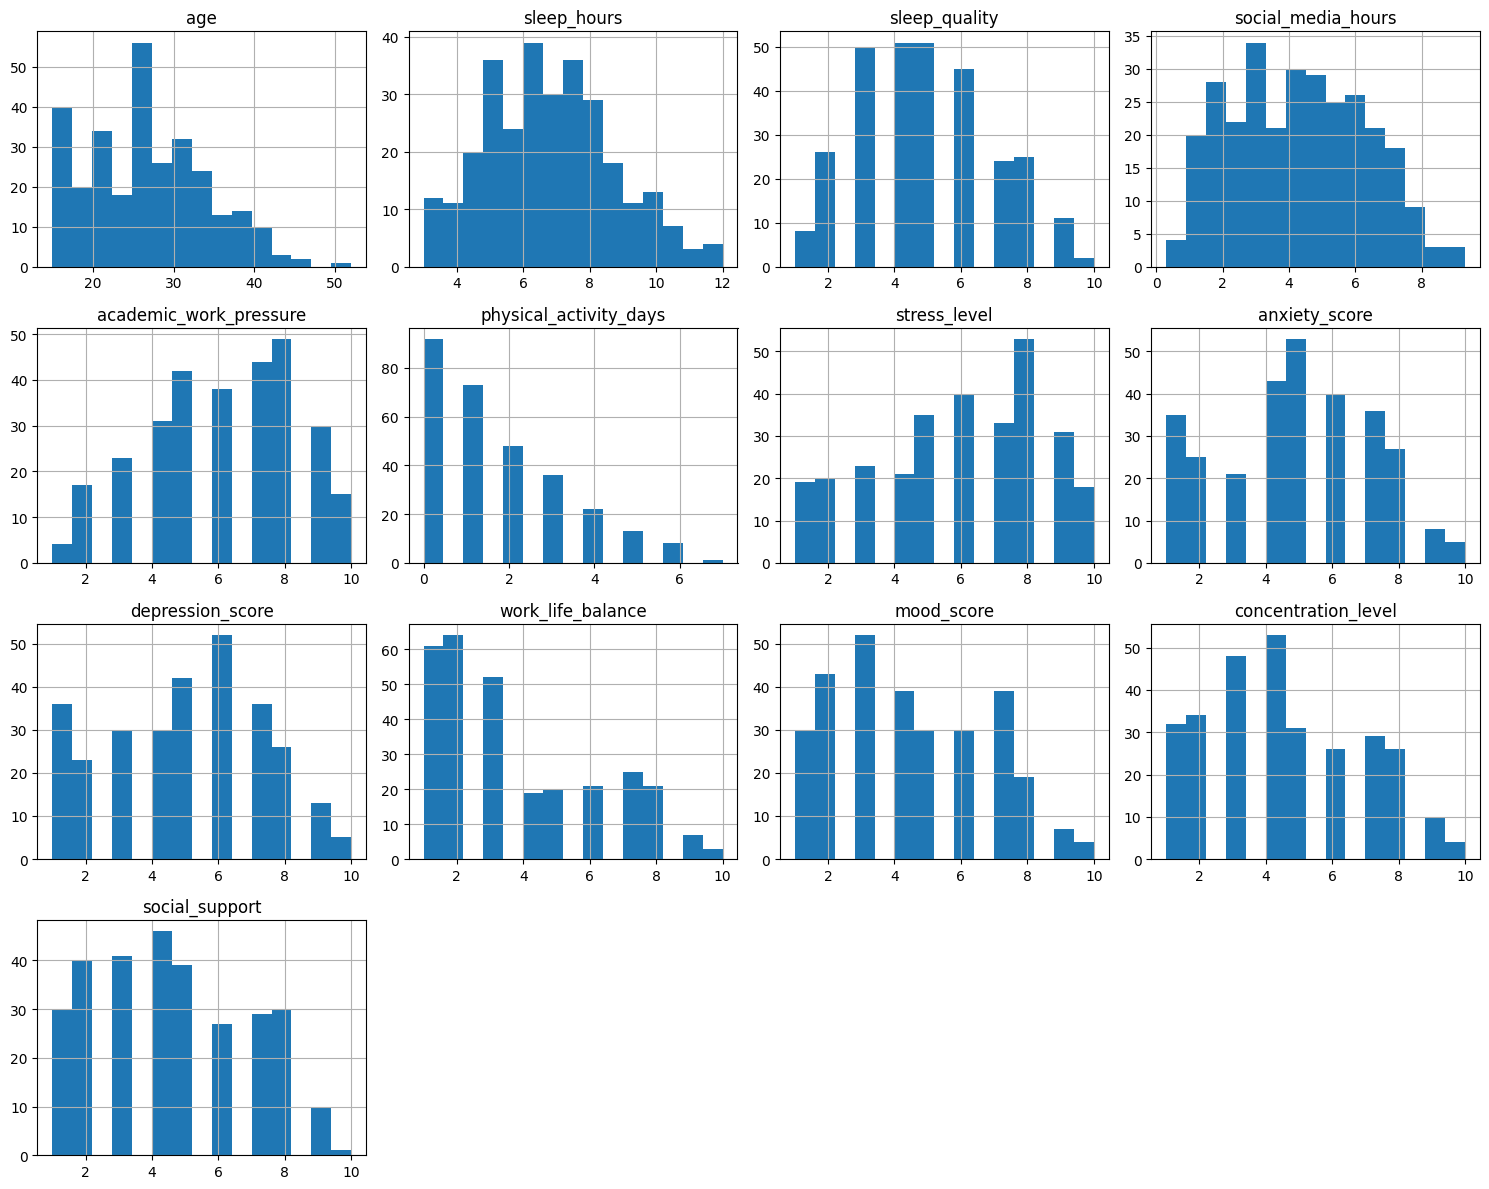

In [78]:
df[numeric_cols].hist(bins=15, figsize=(15, 12))
plt.tight_layout()
plt.show()

In [79]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [87]:
target_col = "mental_health_condition"
leaking_cols = ["severity", "treatment"]
X = df.drop(columns=[target_col] + leaking_cols)
y = df[target_col]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

categorical_features = X.select_dtypes(include=["object"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [91]:
y_pred = model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.9153
              precision    recall  f1-score   support

     Anxiety       0.87      0.87      0.87        15
     Burnout       0.88      0.93      0.90        15
  Depression       0.92      0.86      0.89        14
      Normal       1.00      1.00      1.00        15

    accuracy                           0.92        59
   macro avg       0.92      0.91      0.91        59
weighted avg       0.92      0.92      0.92        59

